In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [121]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [122]:
df.shape

(918, 12)

In [123]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [125]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [127]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [128]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

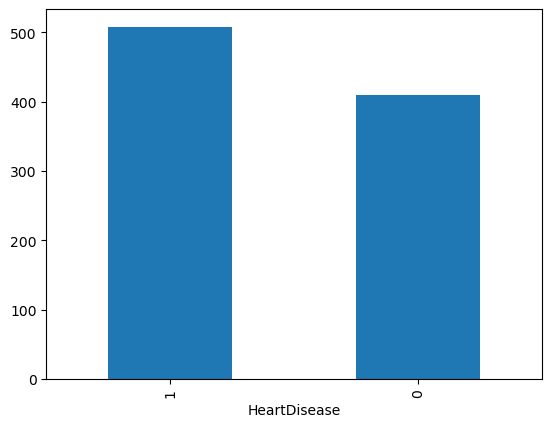

In [129]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [130]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [142]:
numeric_columns = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']

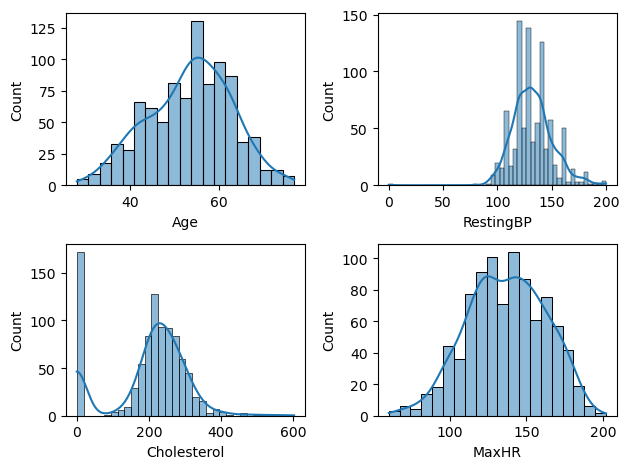

In [145]:
def plotting(feature, plot_num):
    plt.subplot(2,2, plot_num)
    sns.histplot(df[feature], kde=True)

for i, col in enumerate(numeric_columns, start=1):
    plotting(col, i)

plt.tight_layout()


In [146]:
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [151]:
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean.round(2))

In [152]:
df['Cholesterol'].value_counts()

Cholesterol
244.635389    172
254.000000     11
223.000000     10
220.000000     10
230.000000      9
             ... 
392.000000      1
316.000000      1
153.000000      1
466.000000      1
131.000000      1
Name: count, Length: 222, dtype: int64

<Axes: xlabel='Cholesterol', ylabel='Count'>

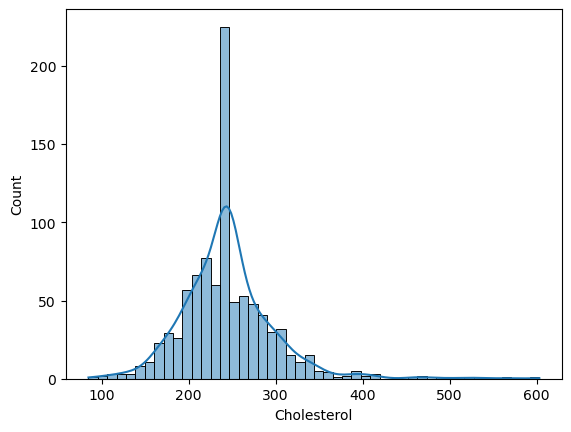

In [155]:
sns.histplot(df, x='Cholesterol', kde=True)

In [175]:
restingBPmean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean().round(2)
restingBPmean

np.float64(132.54)

In [176]:
df['RestingBP'] = df['RestingBP'].replace(0, restingBPmean)

<Axes: xlabel='RestingBP', ylabel='Count'>

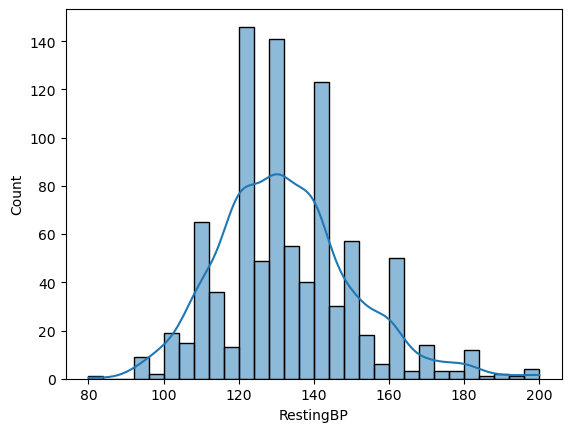

In [177]:
sns.histplot(df, x='RestingBP', kde=True)

<Axes: xlabel='ChestPainType', ylabel='count'>

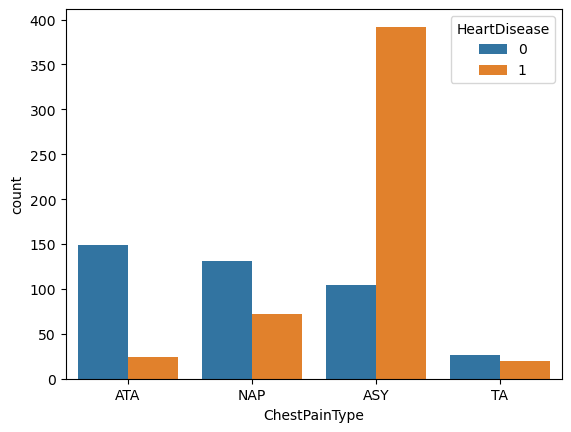

In [178]:
sns.countplot(df, x='ChestPainType', hue='HeartDisease')

<Axes: xlabel='Sex', ylabel='count'>

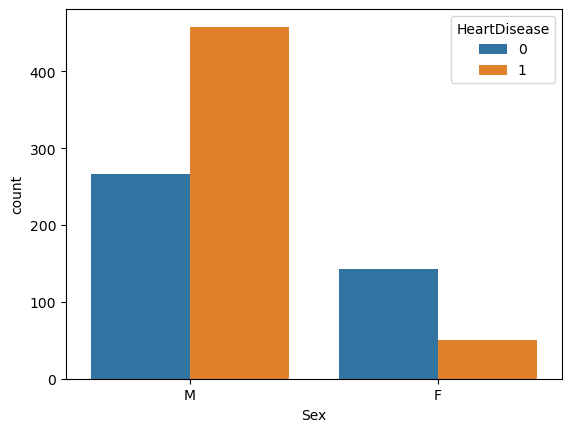

In [179]:
sns.countplot(df, x='Sex', hue='HeartDisease')

<Axes: xlabel='FastingBS', ylabel='count'>

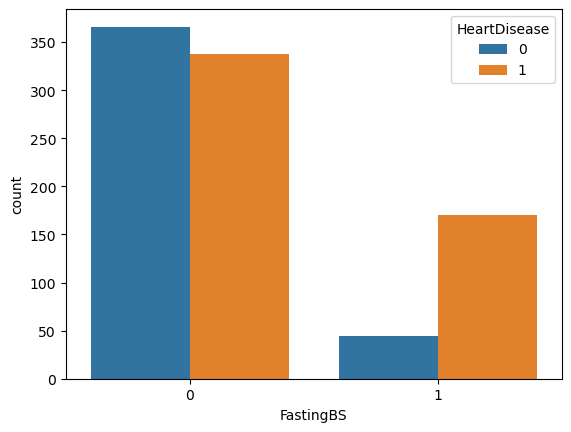

In [185]:
sns.countplot(df, x='FastingBS', hue='HeartDisease')

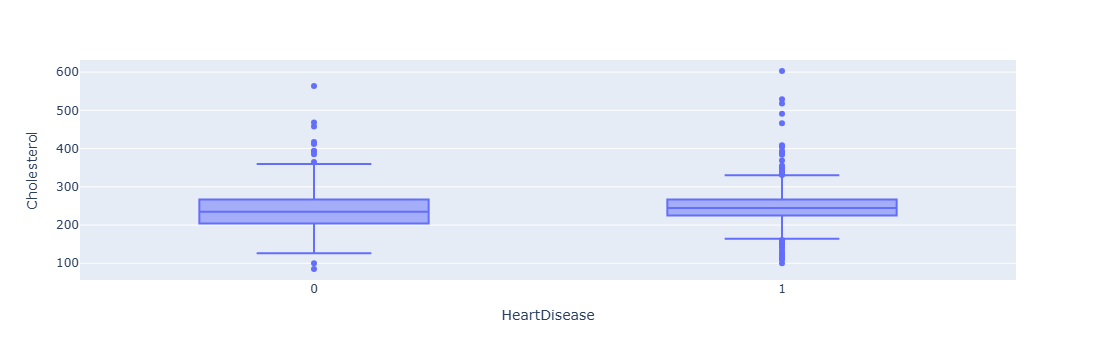

In [186]:
px.box(df, x='HeartDisease', y='Cholesterol')

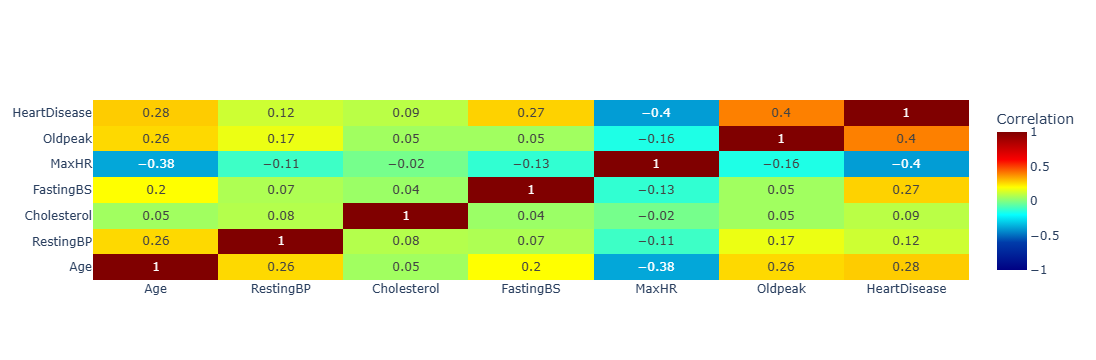

In [194]:
corr = df.corr(numeric_only=True).round(2)

go.Figure(
    go.Heatmap(
        x=corr.columns,
        y=corr.index,
        z=corr.values,
        zmin=-1,
        zmax=1,
        colorscale='Jet',
        colorbar=dict(title="Correlation"),
        texttemplate= "%{z}"
    )
)

In [195]:
df_encode = pd.get_dummies(df, drop_first=True)

In [196]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [201]:
df_encode = df_encode.astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [206]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

df_encode[cols] = scaler.fit_transform(df_encode[cols])

In [207]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [208]:
from scipy.stats import pearsonr

In [212]:
selected_columns = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 
        'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

correlation = {
    feature: pearsonr(df_encode[feature], df_encode['HeartDisease'])[0]
    for feature in selected_columns
}

In [213]:
correlation

{'Age': np.float64(0.28203850581899725),
 'RestingBP': np.float64(0.11790857244927674),
 'Cholesterol': np.float64(0.09258582507897908),
 'FastingBS': np.float64(0.2672911861102983),
 'MaxHR': np.float64(-0.40042076946319016),
 'Oldpeak': np.float64(0.39238540391984317),
 'Sex_M': np.float64(0.30544491596314066),
 'ChestPainType_ATA': np.float64(-0.4019240529146675),
 'ChestPainType_NAP': np.float64(-0.21296362503940588),
 'ChestPainType_TA': np.float64(-0.05479026202691396),
 'RestingECG_Normal': np.float64(-0.09157996051345986),
 'RestingECG_ST': np.float64(0.10252722218986658),
 'ExerciseAngina_Y': np.float64(0.494281991824268),
 'ST_Slope_Flat': np.float64(0.5541335908840073),
 'ST_Slope_Up': np.float64(-0.622164208395995)}

In [217]:
corr_df = pd.DataFrame(list(correlation.items()), columns=['Feature', 'Correlation'])
corr_df.sort_values(by="Correlation", ascending=False)

,Feature,Correlation
13,ST_Slope_Flat,0.554134
12,ExerciseAngina_Y,0.494282
5,Oldpeak,0.392385
6,Sex_M,0.305445
0,Age,0.282039
3,FastingBS,0.267291
1,RestingBP,0.117909
11,RestingECG_ST,0.102527
2,Cholesterol,0.092586
9,ChestPainType_TA,-0.054790


In [230]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [231]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [232]:
df['FastingBS'].unique()

array([0, 1])

In [242]:
cat_features = ['Age', 'FastingBS', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

In [243]:
from scipy.stats import chi2_contingency

In [252]:
alpha = 0.05

df_encode['HeartDisease_bin'] = df_encode['HeartDisease']
df_encode['Age_bin'] = pd.cut(df_encode['Age'], bins=5)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_encode[col], df_encode['HeartDisease_bin'])
    chi2_stats, p_value, _, _ = chi2_contingency(contingency)

    decision = "Reject Null Hypothesis (Keep feature)" if p_value < alpha else "Accept Null hypothesis (Drop feature)"

    chi2_results[col] = {
        'chi2_statistics' : chi2_stats,
        'p_value' : p_value,
        'decision' : decision
    }
    

In [253]:
chi2_df = pd.DataFrame(chi2_results).T
chi2_df.sort_values(by='p_value', ascending=False)

,chi2_statistics,p_value,decision
ChestPainType_TA,2.273802,0.131577,Accept Null hypothesis (Drop feature)
RestingECG_Normal,7.327532,0.006791,Reject Null Hypothesis (Keep feature)
RestingECG_ST,9.135266,0.002507,Reject Null Hypothesis (Keep feature)
Age,125.365667,0.0,Reject Null Hypothesis (Keep feature)
ChestPainType_NAP,40.608711,0.0,Reject Null Hypothesis (Keep feature)
FastingBS,64.320679,0.0,Reject Null Hypothesis (Keep feature)
Sex_M,84.145101,0.0,Reject Null Hypothesis (Keep feature)
ChestPainType_ATA,146.236323,0.0,Reject Null Hypothesis (Keep feature)
ExerciseAngina_Y,222.259383,0.0,Reject Null Hypothesis (Keep feature)
ST_Slope_Flat,279.659914,0.0,Reject Null Hypothesis (Keep feature)


In [254]:
final_df = df_encode.drop('ChestPainType_TA', axis=1)

In [255]:
final_df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,HeartDisease_bin,Age_bin
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,1,0,0,0,1,0,"(-1.667, -0.627]"
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,1,0,0,1,0,1,"(-0.627, 0.413]"
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,1,0,0,1,0,"(-2.711, -1.667]"
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,1,0,1,1,0,1,"(-0.627, 0.413]"
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,1,0,0,0,1,0,"(-0.627, 0.413]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.365619,0,-0.188999,0.282891,1,1,0,0,1,0,0,1,0,1,"(-1.667, -0.627]"
914,1.536902,0.637353,-0.966725,1,0.164684,2.303858,1,1,0,0,1,0,0,1,0,1,"(1.452, 2.492]"
915,0.370100,-0.141284,-2.130180,0,-0.857069,0.282891,1,1,0,0,1,0,1,1,0,1,"(-0.627, 0.413]"
916,0.370100,-0.141284,-0.159813,0,1.461525,-0.727592,1,0,1,0,0,0,0,1,0,1,"(-0.627, 0.413]"
